# Light-curve classification

Classifies [Roman Open Universe hourglass simulation](https://zenodo.org/records/14262943)
transients (top-5 classes) using ATCAT multiband embeddings
and a linear Ridge classifier with 5-fold cross-validation.

## Step 0 — Install dependencies

Install in command-line with:

```
pip install light-curve nested-pandas scikit-learn matplotlib
```

or uncomment the cell bellow:

In [1]:
# %pip install light-curve nested-pandas scikit-learn matplotlib

## Step 1 — Download and sample

Download the Hourglass objects and photometry tables from Zenodo, keep the five most
common transient classes, and save the joined
nested-pandas frame as a Parquet file for later use.

In [2]:
import os
import tempfile
import urllib.request

import nested_pandas as npd
import pandas as pd

ZENODO = "https://zenodo.org/records/14262943/files"
CACHE = os.path.join(tempfile.gettempdir(), "hourglass_zenodo")
SAMPLE_PATH = os.path.join(CACHE, "roman_sample.parquet")
os.makedirs(CACHE, exist_ok=True)

for fname in ("hourglass_objects.parquet", "hourglass_photometry.parquet"):
    dest = os.path.join(CACHE, fname)
    if not os.path.exists(dest):
        print(f"Downloading {fname}\u2026")
        urllib.request.urlretrieve(f"{ZENODO}/{fname}?download=1", dest)

objects = npd.read_parquet(os.path.join(CACHE, "hourglass_objects.parquet"))
top5 = objects["class"].value_counts().head(5).index.tolist()
print(f"Top-5 classes: {top5}")

sample = objects[objects["class"].isin(top5)]
print(f"Sample: {len(sample):,} objects")
print(sample["class"].value_counts().to_string())

photometry = pd.read_parquet(os.path.join(CACHE, "hourglass_photometry.parquet"))
nf = npd.NestedFrame(sample).join_nested(photometry, name="lc", on="cid")

Top-5 classes: ['CCSN', 'SN_Ia', 'SN_Iax', 'SNIa-91bg', 'Fixed_mag']
Sample: 64,032 objects
class
CCSN         39177
SN_Ia        21731
SN_Iax        1318
SNIa-91bg     1317
Fixed_mag      489


## Step 2 — Embed with ATCAT

Load the sample, run ATCAT (a multiband causal transformer trained on LSST-like light curves)
across four Roman bands (R, Z, Y, J, H, F) mapped to LSST band indices 0–5.
ATCAT takes fluxes (SNANA's `fluxcal`, ZP=27.5) and produces a single 384-dim embedding per object.

This cell took about 7 minutes on a Macbook Pro with M2Pro CPU.

In [3]:
import nested_pandas as npd

from light_curve.embed import ATCAT

CACHE = os.path.join(tempfile.gettempdir(), "hourglass_zenodo")
SAMPLE_PATH = os.path.join(CACHE, "roman_sample.parquet")
EMBED_PATH = os.path.join(CACHE, "roman_embeddings.parquet")

# Roman bands mapped to LSST band indices (0=u 1=g 2=r 3=i 4=z 5=Y)
BAND_GROUP = {"R": 0, "Z": 1, "Y": 2, "J": 3, "H": 4, "F": 5}
EMBED_DIM = 384  # ATCAT embedding dimension (single band group)

nf = npd.read_parquet(SAMPLE_PATH)

# fluxcal is calibrated to AB ZP=27.5 (SNANA/hourglass convention).
# mag_zp=26.0 rescales the fluxes up (~4×), placing Roman flux levels
# closer to the LSST training distribution of ATCAT.
model = ATCAT.from_hf(
    output="mean",
    band_groups=BAND_GROUP,
    mag_zp=26.0,
)
print(f"ATCAT loaded (embed_dim={EMBED_DIM}, seq_size={model.seq_size})")


def embed_row(mjd, flux, flux_err, band, flag):
    ok = (flag == 0)
    mjd, flux, flux_err, band = mjd[ok], flux[ok], flux_err[ok], band[ok]

    emb = model(mjd, flux, flux_err, band=band)  # (1, 1, 1, 384)
    return {"embedding.value": emb.squeeze()}


print("Embedding light curves\u2026")
nf = nf.map_rows(
    embed_row,
    columns=["lc.mjd", "lc.fluxcal", "lc.fluxcal_err", "lc.band", "lc.phot_flag"],
    row_container="args",
    append_columns=True,
)
print("Done.")

embed_nf = nf[["cid", "class", "embedding"]]

/Users/hombit/.virtualenvs/light-curve/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/hombit/projects/light-curve-python/light-curve/light_curve/embed/model.py:60: ExperimentalWarning: light_curve.embed.atcat.ATCAT is experimental and may change in future versions
  warn_experimental(


ATCAT loaded (embed_dim=384, seq_size=243)
Embedding light curves…
Done.


## Step 3 — k-fold classification

Load the embeddings, fit a Ridge classifier with `StratifiedKFold(k=5)`, collect
out-of-fold predictions, and save them together with class labels as a Parquet file.

In [4]:
import numpy as np
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler

CACHE = os.path.join(tempfile.gettempdir(), "hourglass_zenodo")
EMBED_PATH = os.path.join(CACHE, "roman_embeddings.parquet")
OOF_PATH = os.path.join(CACHE, "roman_oof.parquet")

X = np.asarray(embed_nf["embedding.value"]).reshape(nf.shape[0], -1)

le = LabelEncoder()
y = le.fit_transform(embed_nf["class"])
class_names = list(le.classes_)
print(f"Classes: {class_names}")

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_pred = np.empty(len(y), dtype=int)

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X[train_idx])
    X_val = scaler.transform(X[val_idx])
    clf = RidgeClassifier(alpha=0.001)
    clf.fit(X_tr, y[train_idx])
    oof_pred[val_idx] = clf.predict(X_val)
    fold_f1 = f1_score(y[val_idx], oof_pred[val_idx], average="macro", zero_division=0)
    print(f"  Fold {fold + 1}/5  macro F1 = {fold_f1:.4f}")

macro_f1 = f1_score(y, oof_pred, average="macro", zero_division=0)
print(f"\nOOF macro F1: {macro_f1:.4f}")
print("\nClassification report (5-fold OOF):")
print(classification_report(y, oof_pred, target_names=class_names, zero_division=0))

# Store class_names in parquet metadata so Step 4 doesn't need a separate file
oof_df = npd.NestedFrame({
    "cid": embed_nf["cid"],
    "class": embed_nf["class"],
    "y_true": y,
    "y_pred": oof_pred,
})

assert macro_f1 > 0.45, f"Expected macro F1 > 0.45, got {macro_f1:.4f}"

Classes: ['CCSN', 'Fixed_mag', 'SNIa-91bg', 'SN_Ia', 'SN_Iax']
  Fold 1/5  macro F1 = 0.6515
  Fold 2/5  macro F1 = 0.6565
  Fold 3/5  macro F1 = 0.6533
  Fold 4/5  macro F1 = 0.6498
  Fold 5/5  macro F1 = 0.6554

OOF macro F1: 0.6533

Classification report (5-fold OOF):
              precision    recall  f1-score   support

        CCSN       0.93      0.97      0.95     39177
   Fixed_mag       0.96      0.93      0.94       489
   SNIa-91bg       0.90      0.29      0.43      1317
       SN_Ia       0.91      0.95      0.93     21731
      SN_Iax       1.00      0.00      0.01      1318

    accuracy                           0.93     64032
   macro avg       0.94      0.63      0.65     64032
weighted avg       0.93      0.93      0.91     64032



## Step 4 — Metrics and plots

Load the OOF predictions and visualise the confusion matrix normalised by **purity**
(column-normalised): each column sums to 100 %, and the diagonal entry equals precision.
Classes are ordered from most similar (Ia subtypes) to least (Fixed_mag).

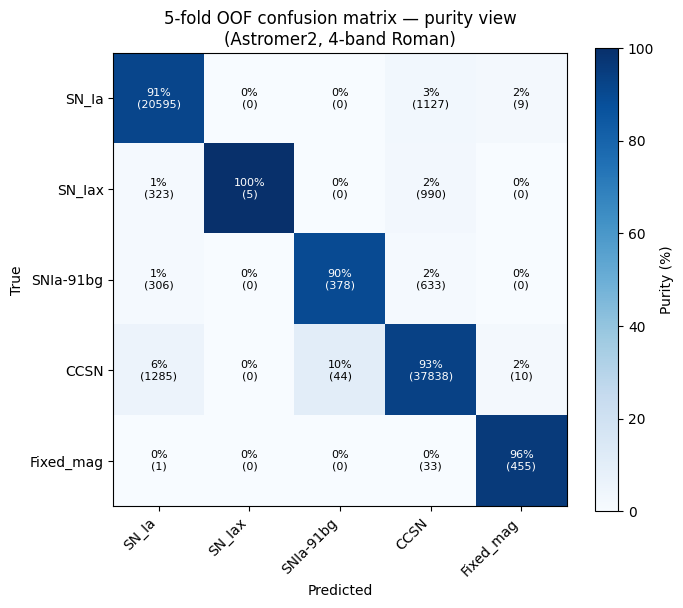

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

y = np.asarray(oof_df["y_true"])
oof_pred = np.asarray(oof_df["y_pred"])

cm = confusion_matrix(y, oof_pred)

ORDER = ["SN_Ia", "SN_Iax", "SNIa-91bg", "CCSN", "Fixed_mag"]
idx = [class_names.index(c) for c in ORDER]
cm = cm[np.ix_(idx, idx)]

col_sums = cm.sum(axis=0, keepdims=True)
cm_purity = np.where(col_sums > 0, cm / col_sums * 100, 0.0)

labels = np.array([
    [f"{p:.0f}%\n({n})" for p, n in zip(row_p, row_n)]
    for row_p, row_n in zip(cm_purity, cm)
])

n = len(ORDER)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_purity, cmap="Blues", vmin=0, vmax=100)
fig.colorbar(im, ax=ax).set_label("Purity (%)")
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(ORDER, rotation=45, ha="right")
ax.set_yticklabels(ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
for i in range(n):
    for j in range(n):
        ax.text(j, i, labels[i, j], ha="center", va="center", fontsize=8,
                color="white" if cm_purity[i, j] > 55 else "black")
ax.set_title("5-fold OOF confusion matrix \u2014 purity view\n(Astromer2, 4-band Roman)")
plt.tight_layout()
plt.show()

Each column shows the **purity** of a predicted class: the fraction of objects classified
as that class which truly belong to it.  The diagonal entry equals precision; off-diagonal
entries are contamination from other classes.

The Ia subtypes (SN_Ia, SN_Iax, SNIa-91bg) are the hardest to separate — they share
similar rise times and peak luminosities.  CCSN and Fixed_mag are well-isolated.